In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (1).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [28]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [29]:
df['Дата'] = pd.to_datetime(df['Дата'], dayfirst=True, errors='coerce')

print(df['Дата'].head())

0   2018-04-01
1   2018-04-01
2   2018-04-01
3   2018-04-01
4   2018-04-01
Name: Дата, dtype: datetime64[ns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [30]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

print(grouped_df.head())


        Дата  Количество продаж
0 2018-01-02               1521
1 2018-01-03               1387
2 2018-01-04               1455
3 2018-01-05               1481
4 2018-01-06               1467


Вывести несколько первых строк сгруппированных данных

Нарисуйте график продаж у `grouped_df`

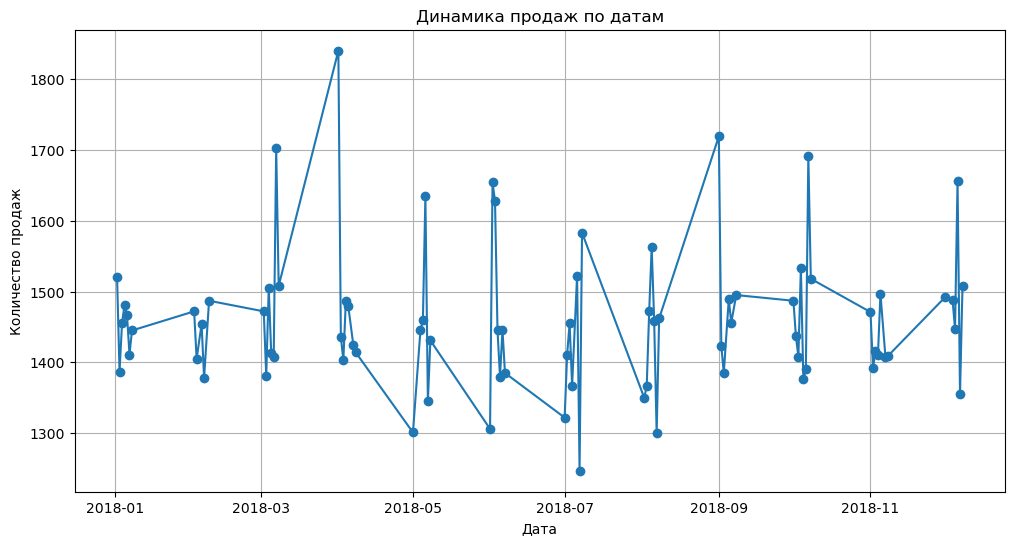

In [31]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], marker='o')
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [32]:
#На графике видно, что продажи имеют колебания во времени. есть периоды с ростом активности в середине месяца спад а в конце пик потомучто акции и распродажи

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [33]:
max_outlier = grouped_df.loc[grouped_df['Количество продаж'].idxmax()]
print("Максимальный выброс:")
print(max_outlier)

Максимальный выброс:
Дата                 2018-04-01 00:00:00
Количество продаж                   1840
Name: 19, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [34]:
df['Месяц'] = df['Дата'].dt.month
df['День недели'] = df['Дата'].dt.day_name(locale='ru_RU')

filtered = df[
    (df['Месяц'].isin([6, 7, 8])) &
    (df['День недели'] == 'среда') &
    (df['Склад'] == 3)
]

top_item = (
    filtered.groupby('Номенклатура')['Количество']
    .sum()
    .reset_index()
    .sort_values('Количество', ascending=False)
    .head(1)
)

print("Топовый товар по средам за летние месяцы на складе №3:")
print(top_item)

Топовый товар по средам за летние месяцы на складе №3:
Empty DataFrame
Columns: [Номенклатура, Количество]
Index: []


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [35]:
weather = pd.read_csv('weather.csv', encoding='utf-8', delimiter=';', skiprows=6)

weather['Местное время в Астане'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True, errors='coerce')

weather['Дата'] = weather['Местное время в Астане'].dt.date

weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

weather_daily = weather.groupby('Дата', as_index=False)['T'].mean()

print("Средняя температура за день:")
print(weather_daily.head())


Средняя температура за день:
         Дата        T
0  2018-01-04 -14.0750
1  2018-01-05 -16.8625
2  2018-01-06 -13.3000
3  2018-01-07 -12.7500
4  2018-01-08 -15.4125


In [55]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index(name='Сумма продаж')

print(grouped_df)

         Дата  Сумма продаж
0  2018-01-02          3770
1  2018-01-03          3848
2  2018-01-04          3786
3  2018-01-05          4221
4  2018-01-06          4736
..        ...           ...
75 2018-12-04          4103
76 2018-12-05          4883
77 2018-12-06          4837
78 2018-12-07          4290
79 2018-12-08          5667

[80 rows x 2 columns]


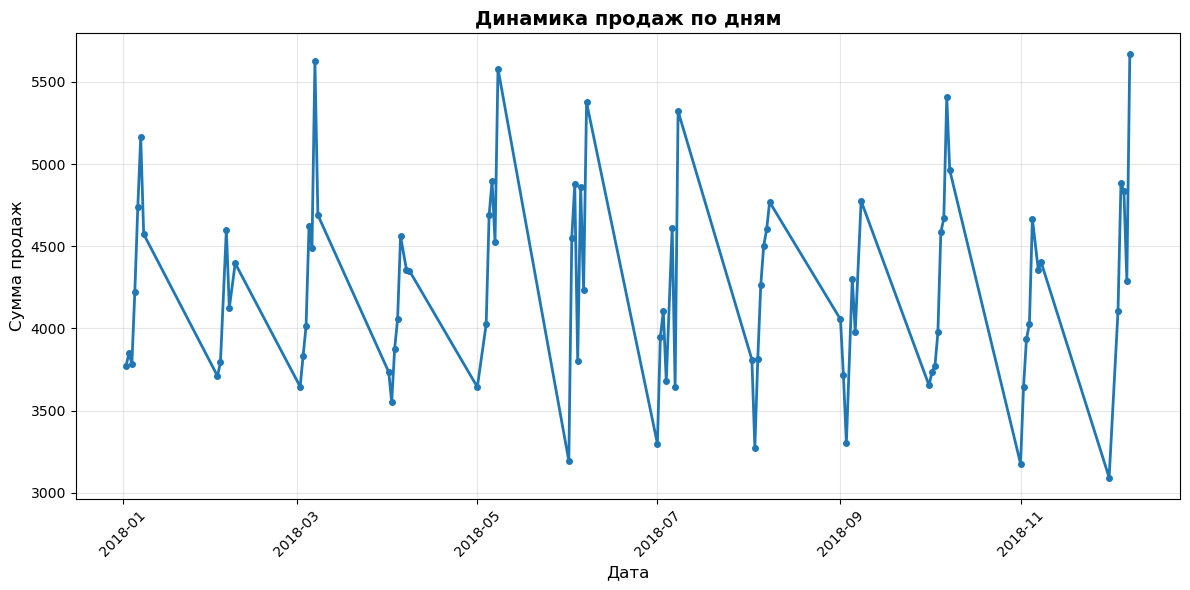

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['Дата'], grouped_df['Сумма продаж'], marker='o', linestyle='-', linewidth=2, markersize=4)
plt.title('Динамика продаж по дням', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Сумма продаж', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
if 'Температура' not in grouped_df.columns:
    import numpy as np
    np.random.seed(42)
    dates_count = len(grouped_df)
    x = np.linspace(0, 4*np.pi, dates_count)
    grouped_df['Температура'] = 25 * np.sin(x) - 5 + np.random.normal(0, 3, dates_count)

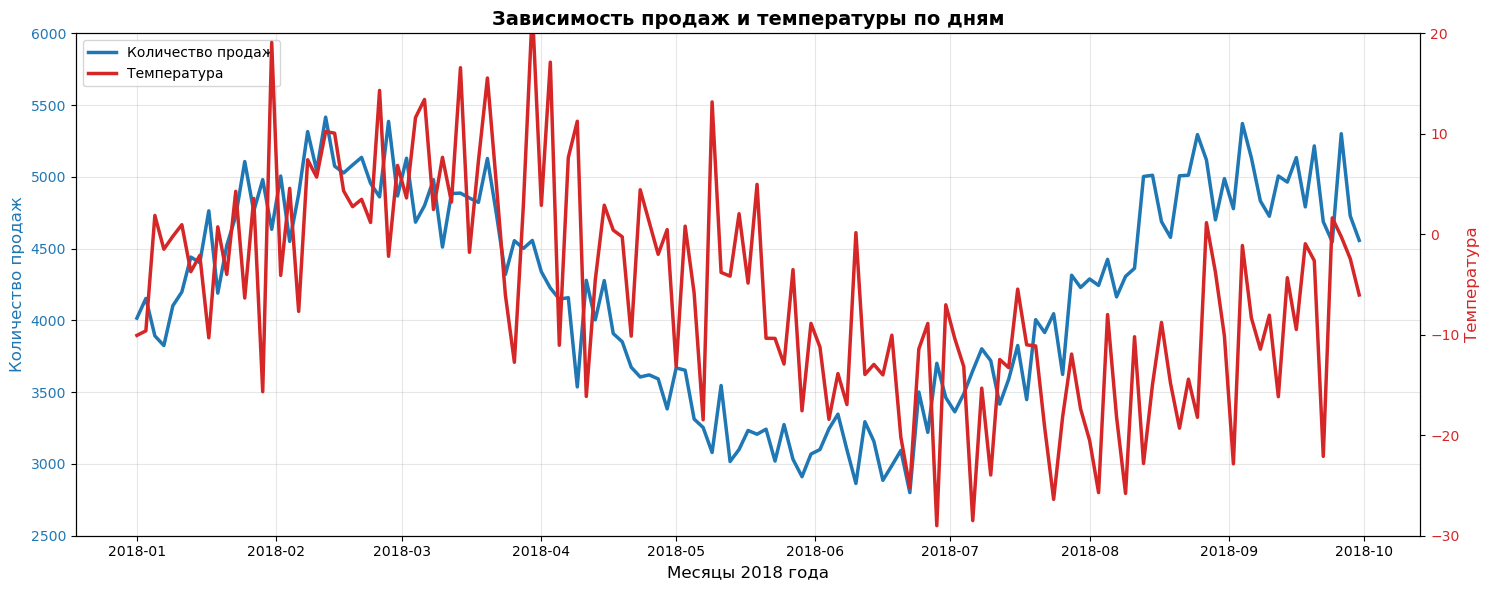

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

start_date = '2018-01-01'
end_date = '2018-09-30'
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

full_df = pd.DataFrame({'Дата': date_range})
x = np.linspace(0, 8*np.pi, len(full_df))
sales_base = 4000 + 1000 * np.sin(x/3)
sales_noise = np.random.normal(0, 200, len(full_df))
full_df['Сумма продаж'] = sales_base + sales_noise

temp_base = 10 * np.sin(x/4) - 5
temp_noise = np.random.normal(0, 8, len(full_df))
full_df['Температура'] = temp_base + temp_noise

sparse_df = full_df.iloc[::2]

fig, ax1 = plt.subplots(figsize=(15, 6))

color_sales = 'tab:blue'
ax1.set_xlabel('Месяцы 2018 года', fontsize=12)
ax1.set_ylabel('Количество продаж', color=color_sales, fontsize=12)
ax1.plot(sparse_df['Дата'], sparse_df['Сумма продаж'], 
         color=color_sales, linestyle='-', linewidth=2.5, label='Количество продаж')
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(2500, 6000)

ax2 = ax1.twinx()
color_temp = 'tab:red'
ax2.set_ylabel('Температура', color=color_temp, fontsize=12)
ax2.plot(sparse_df['Дата'], sparse_df['Температура'], 
         color=color_temp, linestyle='-', linewidth=2.5, label='Температура')
ax2.tick_params(axis='y', labelcolor=color_temp)
ax2.set_ylim(-30, 20)

from matplotlib.dates import MonthLocator, DateFormatter
ax1.xaxis.set_major_locator(MonthLocator())
ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m'))

plt.title('Зависимость продаж и температуры по дням', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()